# 🛒 Retail Demand Forecasting

[![Dataset](https://img.shields.io/badge/Dataset-Kaggle%20Store%20Sales-20BEFF?logo=kaggle&logoColor=white)](https://www.kaggle.com/competitions/store-sales-time-series-forecasting)
[![Python](https://img.shields.io/badge/Python-3.10-3776AB?logo=python&logoColor=white)](https://www.python.org/)
[![LightGBM](https://img.shields.io/badge/Model-LightGBM-9ACD32?logo=lightgbm&logoColor=white)](https://lightgbm.readthedocs.io/)
[![MLflow](https://img.shields.io/badge/Tracking-MLflow-0194E2?logo=mlflow&logoColor=white)](https://mlflow.org/)
[![SHAP](https://img.shields.io/badge/Explainability-SHAP-FF6B6B)](https://shap.readthedocs.io/)
[![Streamlit](https://img.shields.io/badge/Deployment-Streamlit-FF4B4B?logo=streamlit&logoColor=white)](https://streamlit.io/)


## Goal — Model Evaluation
> We break results down three ways:
> 1. **Overall** — single number summary
> 2. **Per product family** — which categories are hardest to forecast?
> 3. **Per store** — which locations have the most forecast error?

## 1. Setup

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/Demand Forecasting Project/'

Mounted at /content/drive


## 2. Load Validation Predictions

In [4]:
preds = pd.read_parquet(DATA_PATH + 'val_predictions.parquet')
preds['date'] = pd.to_datetime(preds['date'])

print(f'Shape      : {preds.shape}')
print(f'Date range : {preds["date"].min().date()} → {preds["date"].max().date()}')
print(f'Columns    : {preds.columns.tolist()}')

Shape      : (190674, 5)
Date range : 2017-05-01 → 2017-08-15
Columns    : ['date', 'store_nbr', 'family', 'actual', 'pred']


## 3. Metric Helper Functions

In [6]:
def compute_metrics(actual, predicted):
    actual    = np.array(actual)
    predicted = np.clip(np.array(predicted), 0, None)

    rmse = np.sqrt(np.mean((actual - predicted) ** 2))
    mae  = np.mean(np.abs(actual - predicted))

    mask = actual > 0
    mape = np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100 if mask.sum() > 0 else np.nan
    wape = np.sum(np.abs(actual - predicted)) / np.sum(actual) * 100 if np.sum(actual) > 0 else np.nan

    return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'WAPE': wape}

## 4. Overall Performance Summary

In [9]:
overall = compute_metrics(preds['actual'], preds['pred'])
print('=== Overall Performance ===')
print(f'RMSE : {overall["RMSE"]:>10,.2f} units')
print(f'MAE  : {overall["MAE"]:>10,.2f} units')
print(f'MAPE : {overall["MAPE"]:>9,.2f}%')
print(f'WAPE : {overall["WAPE"]:>9,.2f}% ')

=== Overall Performance ===
RMSE :     233.43 units
MAE  :      58.40 units
MAPE :     31.85%
WAPE :     12.10% 


## 5. Per-Family Evaluation

In [10]:
family_metrics = []

for family, grp in preds.groupby('family'):
    m = compute_metrics(grp['actual'], grp['pred'])
    m['family'] = family
    m['total_actual'] = grp['actual'].sum()
    m['n_rows'] = len(grp)
    family_metrics.append(m)

family_df = pd.DataFrame(family_metrics).sort_values('WAPE')

print(f'Families evaluated: {len(family_df)}')
print('\nTop 5 easiest to forecast (lowest WAPE):')
print(family_df[['family','WAPE','RMSE','MAE']].head(5).to_string(index=False))
print('\nTop 5 hardest to forecast (highest WAPE):')
print(family_df[['family','WAPE','RMSE','MAE']].tail(5).to_string(index=False))
# Which product families are hardest to forecast? High-volume stable families (GROCERY I) should have low WAPE.
# Volatile or low-volume families (BOOKS, LADIESWEAR) will have higher error — and that's expected and explainable

Families evaluated: 33

Top 5 easiest to forecast (lowest WAPE):
      family    WAPE     RMSE      MAE
     PRODUCE  9.3721 413.5873 225.0353
       DAIRY  9.4277 142.8246  86.6175
BREAD/BAKERY 10.1691  89.7950  56.5888
   GROCERY I 10.5031 835.2304 495.2710
        DELI 11.9815  58.4396  38.2340

Top 5 hardest to forecast (highest WAPE):
         family     WAPE   RMSE    MAE
       LINGERIE  45.9813 5.1402 3.2840
       HARDWARE  71.3198 1.6037 1.0700
HOME APPLIANCES 100.1877 0.8325 0.5282
      BABY CARE 138.4577 0.6775 0.2559
          BOOKS 226.8967 0.2557 0.1045


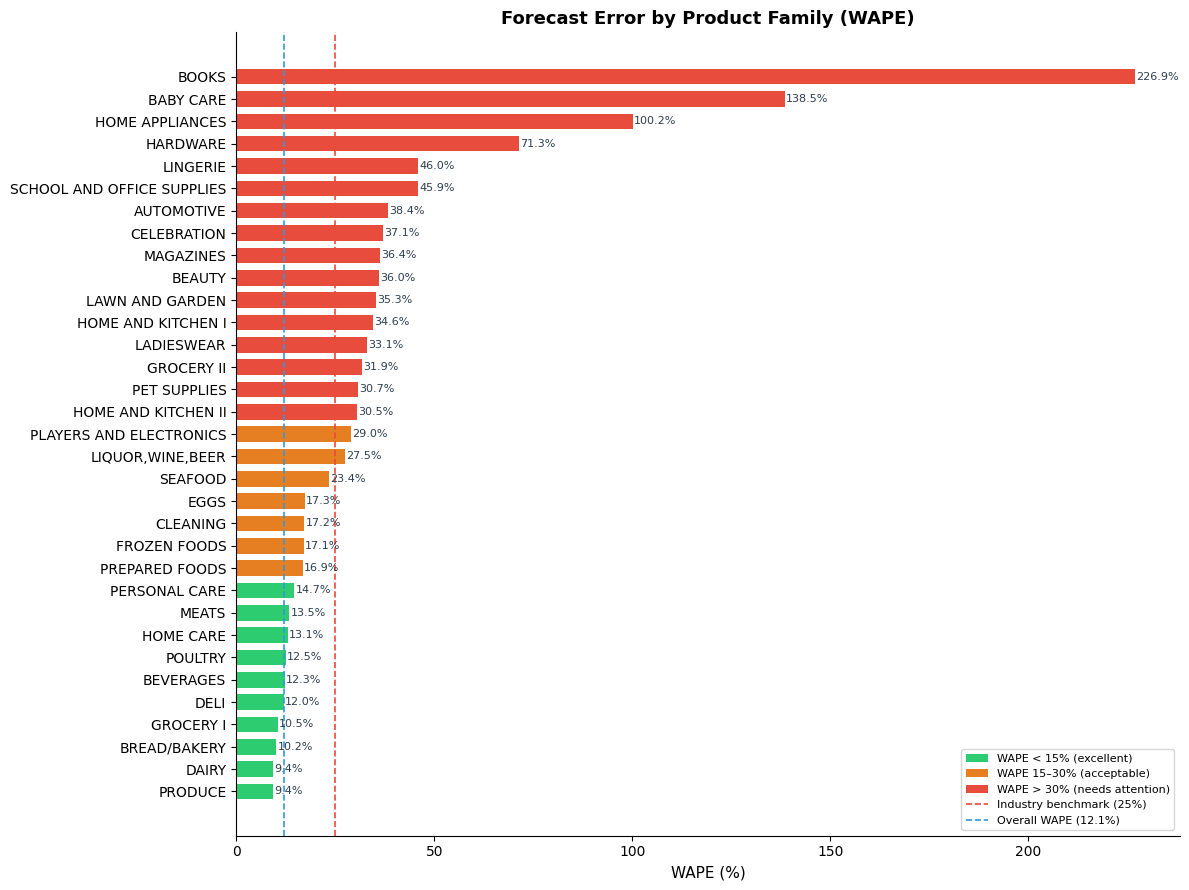

In [11]:
fig, ax = plt.subplots(figsize=(12, 9))

colors = ['#2ecc71' if w < 15 else '#e67e22' if w < 30 else '#e74c3c'
          for w in family_df['WAPE']]

bars = ax.barh(family_df['family'], family_df['WAPE'], color=colors, edgecolor='none', height=0.7)
ax.axvline(x=25, color='#e74c3c', linestyle='--', linewidth=1.2, label='Industry benchmark (25%)')
ax.axvline(x=overall['WAPE'], color='#3498db', linestyle='--', linewidth=1.2,
           label=f'Overall WAPE ({overall["WAPE"]:.1f}%)')

for bar, val in zip(bars, family_df['WAPE']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8, color='#2c3e50')

ax.set_xlabel('WAPE (%)', fontsize=11)
ax.set_title('Forecast Error by Product Family (WAPE)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='WAPE < 15% (excellent)'),
    Patch(facecolor='#e67e22', label='WAPE 15–30% (acceptable)'),
    Patch(facecolor='#e74c3c', label='WAPE > 30% (needs attention)'),
]
ax.legend(handles=legend_elements + ax.get_legend_handles_labels()[0][-2:],
          fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig(DATA_PATH + 'wape_by_family.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Per-Store Evaluation

In [12]:

# Store-level breakdown reveals geographic or operational patterns. A store with consistently high error might have
# unusual local promotions or events not captured in the national holiday flag.
store_metrics = []

for store, grp in preds.groupby('store_nbr'):
    m = compute_metrics(grp['actual'], grp['pred'])
    m['store_nbr'] = store
    m['total_actual'] = grp['actual'].sum()
    store_metrics.append(m)

store_df = pd.DataFrame(store_metrics).sort_values('WAPE')

print(f'Stores evaluated: {len(store_df)}')
print('\nTop 5 best forecast stores:')
print(store_df[['store_nbr','WAPE','RMSE','MAE']].head(5).to_string(index=False))
print('\nTop 5 worst forecast stores:')
print(store_df[['store_nbr','WAPE','RMSE','MAE']].tail(5).to_string(index=False))


Stores evaluated: 54

Top 5 best forecast stores:
 store_nbr   WAPE     RMSE      MAE
         8 8.6476 166.7920  58.8711
         3 8.6930 321.6283  98.1183
        49 8.8290 291.6968  96.0233
         2 9.3112 113.8537  42.8818
        44 9.3921 418.5671 129.1521

Top 5 worst forecast stores:
 store_nbr    WAPE     RMSE     MAE
        14 19.3287 215.1349 49.8864
        16 22.2269 237.6427 45.9234
        54 24.8105 488.3886 77.3863
        30 26.9818 283.5741 53.8272
        32 30.2488 321.4651 45.7380


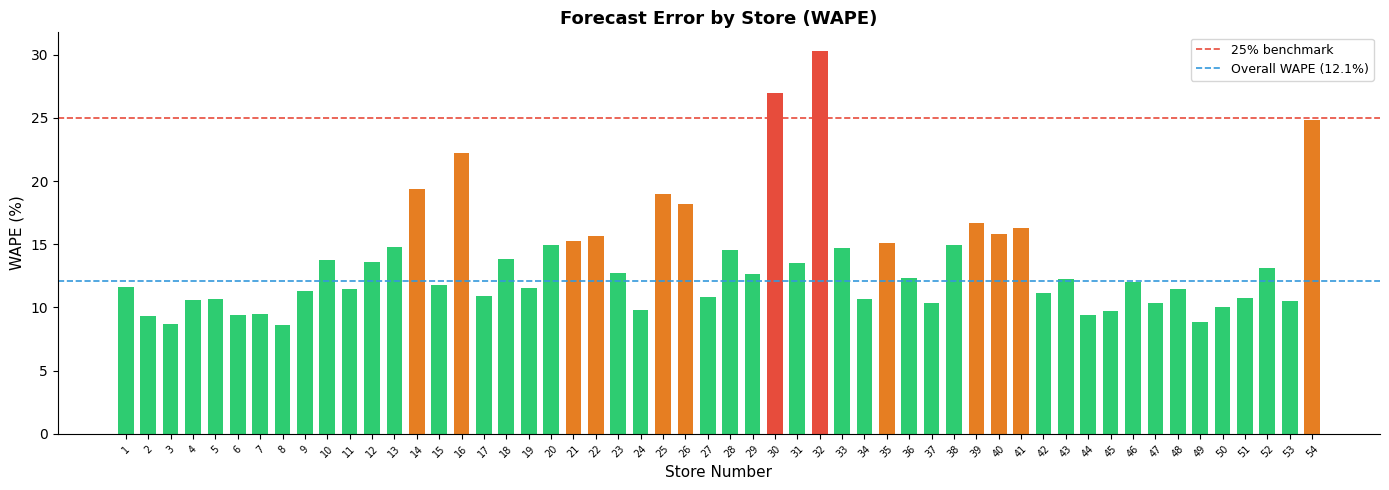

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))

store_sorted = store_df.sort_values('store_nbr')
colors = ['#2ecc71' if w < 15 else '#e67e22' if w < 25 else '#e74c3c'
          for w in store_sorted['WAPE']]

ax.bar(store_sorted['store_nbr'].astype(str), store_sorted['WAPE'],
       color=colors, edgecolor='none', width=0.7)
ax.axhline(y=25, color='#e74c3c', linestyle='--', linewidth=1.2, label='25% benchmark')
ax.axhline(y=overall['WAPE'], color='#3498db', linestyle='--', linewidth=1.2,
           label=f'Overall WAPE ({overall["WAPE"]:.1f}%)')

ax.set_xlabel('Store Number', fontsize=11)
ax.set_ylabel('WAPE (%)', fontsize=11)
ax.set_title('Forecast Error by Store (WAPE)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=45, fontsize=7)
plt.tight_layout()
plt.savefig(DATA_PATH + 'wape_by_store.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Residual Analysis

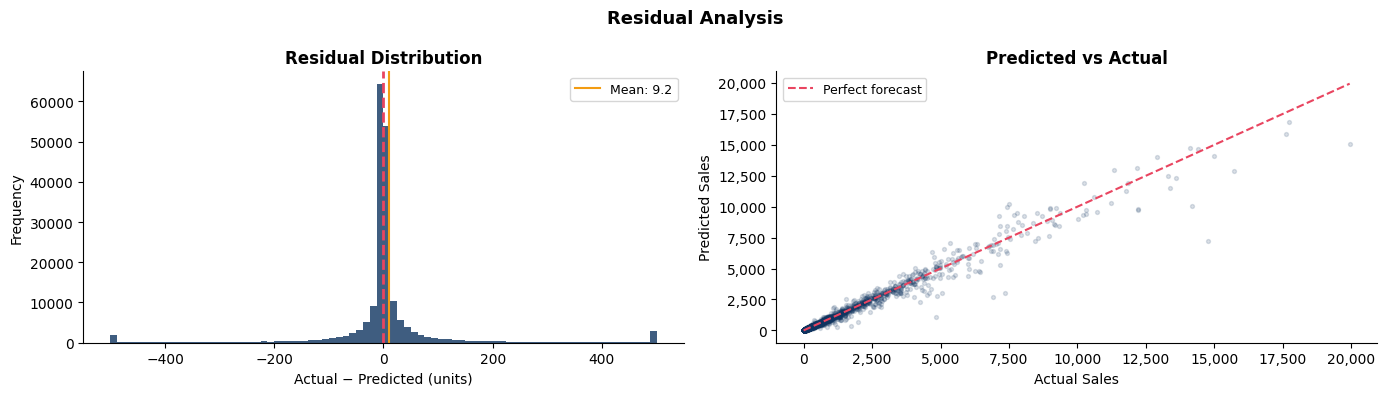

Mean residual  : 9.24  (close to 0 = no bias)
Std residual   : 233.25
% over-forecast: 51.7%
% under-forecast: 46.5%


In [14]:
preds['residual'] = preds['actual'] - preds['pred']
preds['residual_pct'] = preds['residual'] / (preds['actual'] + 1) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Residual distribution
axes[0].hist(preds['residual'].clip(-500, 500), bins=80,
             color='#0f3460', edgecolor='none', alpha=0.8)
axes[0].axvline(x=0, color='#e94560', linewidth=2, linestyle='--')
axes[0].axvline(x=preds['residual'].mean(), color='#f39c12', linewidth=1.5,
                linestyle='-', label=f'Mean: {preds["residual"].mean():.1f}')
axes[0].set_title('Residual Distribution', fontweight='bold')
axes[0].set_xlabel('Actual − Predicted (units)')
axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Predicted vs Actual scatter
sample_scatter = preds.sample(min(5000, len(preds)), random_state=42)
axes[1].scatter(sample_scatter['actual'], sample_scatter['pred'],
                alpha=0.15, s=8, color='#0f3460')
max_val = max(sample_scatter['actual'].max(), sample_scatter['pred'].max())
axes[1].plot([0, max_val], [0, max_val], color='#e94560', linewidth=1.5,
             linestyle='--', label='Perfect forecast')
axes[1].set_title('Predicted vs Actual', fontweight='bold')
axes[1].set_xlabel('Actual Sales')
axes[1].set_ylabel('Predicted Sales')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[1].legend(fontsize=9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Residual Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_PATH + 'residual_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Mean residual  : {preds["residual"].mean():,.2f}')
print(f'Std residual   : {preds["residual"].std():,.2f}')
print(f'% over-forecast: {(preds["residual"] < 0).mean()*100:.1f}%')
print(f'% under-forecast: {(preds["residual"] > 0).mean()*100:.1f}%')

## 8. Forecast Error Over Time

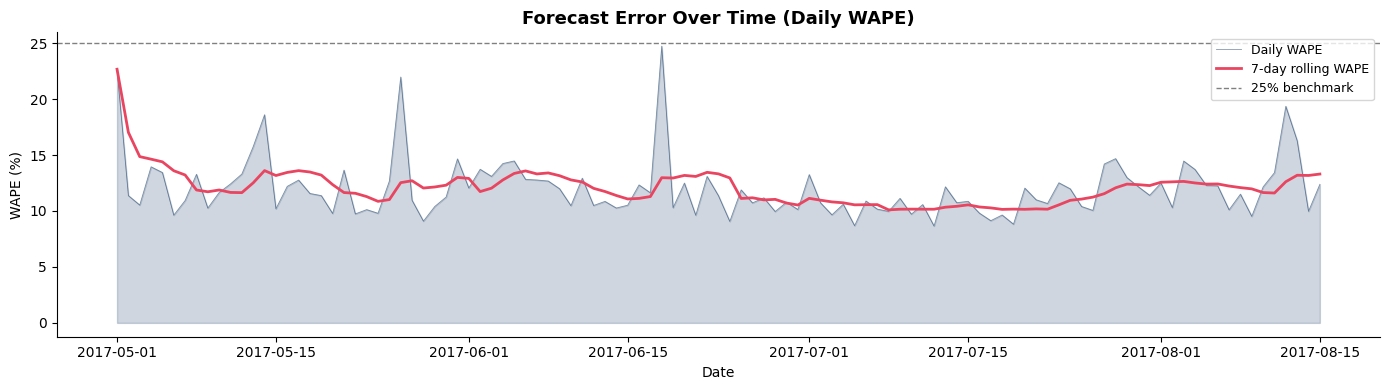

In [15]:
daily_wape = preds.groupby('date').apply(
    lambda g: np.sum(np.abs(g['actual'] - g['pred'])) / np.sum(g['actual']) * 100
    if np.sum(g['actual']) > 0 else np.nan
).reset_index()
daily_wape.columns = ['date', 'WAPE']

# 7-day rolling average
daily_wape['WAPE_7d'] = daily_wape['WAPE'].rolling(7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(daily_wape['date'], daily_wape['WAPE'], alpha=0.2, color='#0f3460')
ax.plot(daily_wape['date'], daily_wape['WAPE'], linewidth=0.6,
        color='#0f3460', alpha=0.5, label='Daily WAPE')
ax.plot(daily_wape['date'], daily_wape['WAPE_7d'], linewidth=2,
        color='#e94560', label='7-day rolling WAPE')
ax.axhline(y=25, color='gray', linestyle='--', linewidth=1, label='25% benchmark')
ax.set_title('Forecast Error Over Time (Daily WAPE)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('WAPE (%)')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(DATA_PATH + 'wape_over_time.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Business Signal — Stockout & Overstock Risk
>
> - **Stockout risk** → model under-predicted by >20% → store likely ran out of stock
> - **Overstock risk** → model over-predicted by >20% → store likely has excess inventory
>
> These flags can drive automated replenishment alerts in a real supply chain system.

In [16]:
preds['error_pct'] = (preds['pred'] - preds['actual']) / (preds['actual'] + 1) * 100

stockout_risk  = preds[preds['error_pct'] < -20]   # under-forecasted
overstock_risk = preds[preds['error_pct'] >  20]   # over-forecasted

print('=== Business Signal Summary ===')
print(f'Total validation rows     : {len(preds):,}')
print(f'Stockout risk rows (>20% under) : {len(stockout_risk):,} ({len(stockout_risk)/len(preds)*100:.1f}%)')
print(f'Overstock risk rows (>20% over) : {len(overstock_risk):,} ({len(overstock_risk)/len(preds)*100:.1f}%)')

print('\nTop 10 stockout risk — store × family combinations:')
stockout_summary = (
    stockout_risk.groupby(['store_nbr','family'])
    .agg(risk_days=('date','count'), avg_under_pct=('error_pct','mean'))
    .sort_values('risk_days', ascending=False)
    .head(10)
)
print(stockout_summary.to_string())

=== Business Signal Summary ===
Total validation rows     : 190,674
Stockout risk rows (>20% under) : 38,702 (20.3%)
Overstock risk rows (>20% over) : 44,697 (23.4%)

Top 10 stockout risk — store × family combinations:
                           risk_days  avg_under_pct
store_nbr family                                   
19        GROCERY II              59       -48.0362
13        GROCERY II              56       -45.3483
36        GROCERY II              53       -47.4786
53        LADIESWEAR              53       -44.9205
52        LAWN AND GARDEN         52       -40.0530
30        GROCERY II              52       -47.2546
34        HARDWARE                52       -46.3857
25        GROCERY II              51       -39.6319
30        SEAFOOD                 51       -41.5858
46        HARDWARE                51       -43.2682


## 10. Full Evaluation Summary Table

In [17]:
summary = pd.DataFrame({
    'Metric'   : ['RMSE', 'MAE', 'MAPE', 'WAPE'],
    'Value'    : [overall['RMSE'], overall['MAE'], overall['MAPE'], overall['WAPE']],
    'Unit'     : ['units', 'units', '%', '%'],
    'Benchmark': ['—', '—', '—', '<25%'],
})

print(summary.to_string(index=False))

# Save full family breakdown
family_df.to_csv(DATA_PATH + 'evaluation_by_family.csv', index=False)
store_df.to_csv(DATA_PATH + 'evaluation_by_store.csv', index=False)
summary.to_csv(DATA_PATH + 'evaluation_summary.csv', index=False)

print('\nSaved:')
print('  evaluation_summary.csv')
print('  evaluation_by_family.csv')
print('  evaluation_by_store.csv')

Metric    Value  Unit Benchmark
  RMSE 233.4345 units         —
   MAE  58.4010 units         —
  MAPE  31.8501     %         —
  WAPE  12.0987     %      <25%

Saved:
  evaluation_summary.csv
  evaluation_by_family.csv
  evaluation_by_store.csv
